# ¿Cómo han evolucionado las técnicas de Machine Learning aplicadas a la detección de ciberataques en redes informáticas durante el período 2018–2024?

In [19]:
!pip install pandas plotly wordcloud matplotlib -q
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/scopus_data.csv')
df.head()

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,DOI,Link,Abstract,Author Keywords,Index Keywords,Document Type,Publication Stage,Open Access,Source,EID
0,Aljehane N.O.; Mengash H.A.; Eltahir M.M.; Alo...,"Aljehane, Nojood O. (57221165542); Mengash, Ha...",57221165542; 56201890800; 57224529665; 5721773...,Golden jackal optimization algorithm with deep...,2024,Alexandria Engineering Journal,86,NaN,NaN,415.0,...,10.1016/j.aej.2023.11.078,https://www.scopus.com/pages/publications/8517...,Network security is essential to our daily com...,Cybersecurity; Deep learning; Intrusion detect...,Computer crime; Cybersecurity; Deep learning; ...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-85178999955
1,Murad N.M.; Dawod A.Y.; Ahmed S.R.; Sekhar R.;...,"Murad, Nada Mohammed (57699844800); Dawod, Adn...",57699844800; 57217133325; 57209730349; 5579262...,Enhancing Network Security: Leveraging Machine...,2025,Intelligent Automation and Soft Computing,40,1.0,NaN,1.0,...,10.32604/iasc.2024.058624,https://www.scopus.com/pages/publications/1050...,This study introduces an innovative hybrid app...,extreme gradient boosting (XGBoost); intrusion...,NaN,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105012545681
2,Alabdulatif A.,"Alabdulatif, Abdullah (57223210745)",57223210745,A Novel Ensemble of Deep Learning Approach for...,2025,Applied Sciences (Switzerland),15,14.0,7984.0,NaN,...,10.3390/app15147984,https://www.scopus.com/pages/publications/1050...,In today’s increasingly interconnected digital...,cybersecurity; deep learning; explainable arti...,Computer crime; Cybersecurity; Data privacy; L...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105011729032
3,Akuthota U.C.; Bhargava L.,"Akuthota, Uday Chandra (58103371700); Bhargava...",58103371700; 14423942100,The role of machine and deep learning in moder...,2025,Computers and Electrical Engineering,124,NaN,110318.0,NaN,...,10.1016/j.compeleceng.2025.110318,https://www.scopus.com/pages/publications/1050...,Network intrusion benchmark datasets serve an ...,Benchmark datasets; Intrusion detection; Machi...,Federated learning; Network intrusion; Benchma...,Article,Final,NaN,Scopus,2-s2.0-105002749993
4,Al-Quayed F.; Ahmad Z.; Humayun M.,"Al-Quayed, Fatima (56487884000); Ahmad, Zulfiq...",56487884000; 57213608630; 56580449600,A Situation Based Predictive Approach for Cybe...,2024,IEEE Access,12,NaN,NaN,34800.0,...,10.1109/ACCESS.2024.3372187,https://www.scopus.com/pages/publications/8518...,Industry 4.0 is fundamentally based on network...,Cybersecurity; detection; intrusions; machine ...,Behavioral research; Computer crime; Cryptogra...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-85186980371


In [9]:
df.shape

(10, 22)

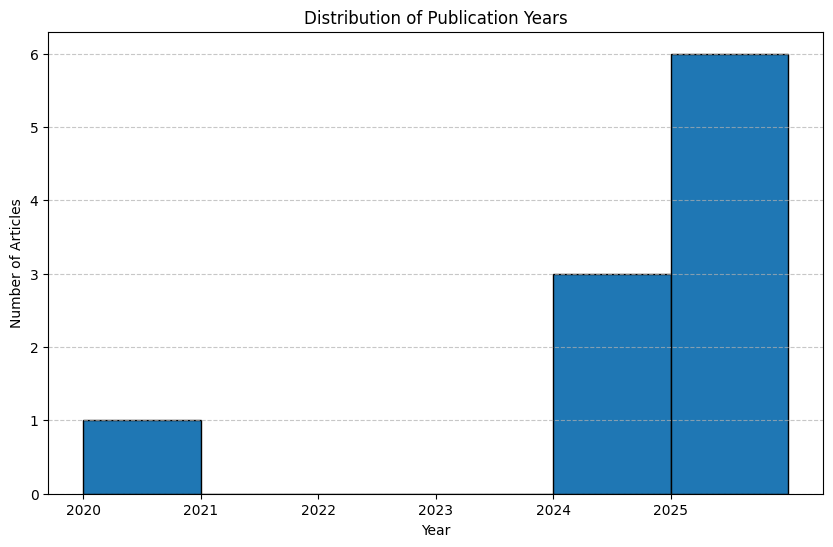

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Year'], bins=range(df['Year'].min(), df['Year'].max() + 2), edgecolor='black')
plt.title('Distribution of Publication Years')
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.xticks(range(df['Year'].min(), df['Year'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
print(df['Cited by'].dtype)

int64


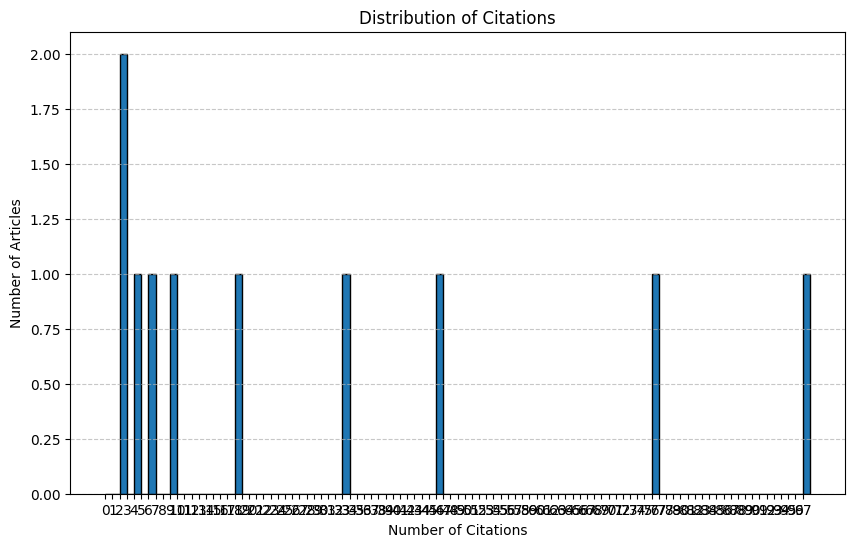

In [14]:
df['Cited by'] = pd.to_numeric(df['Cited by'], errors='coerce')

plt.figure(figsize=(10, 6))
plt.hist(df['Cited by'].dropna(), bins=range(0, int(df['Cited by'].max()) + 2), edgecolor='black')
plt.title('Distribution of Citations')
plt.xlabel('Number of Citations')
plt.ylabel('Number of Articles')
plt.xticks(range(0, int(df['Cited by'].max()) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
# Limpiar columnas
df.columns = df.columns.str.strip()
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Cited by'] = pd.to_numeric(df['Cited by'], errors='coerce').fillna(0).astype(int)

print(f' Dataset cargado: {len(df)} artículos')
print(f' Columnas: {list(df.columns)}')
df.head(3)

 Dataset cargado: 10 artículos
 Columnas: ['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end', 'Cited by', 'DOI', 'Link', 'Abstract', 'Author Keywords', 'Index Keywords', 'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID']


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,DOI,Link,Abstract,Author Keywords,Index Keywords,Document Type,Publication Stage,Open Access,Source,EID
0,Aljehane N.O.; Mengash H.A.; Eltahir M.M.; Alo...,"Aljehane, Nojood O. (57221165542); Mengash, Ha...",57221165542; 56201890800; 57224529665; 5721773...,Golden jackal optimization algorithm with deep...,2024,Alexandria Engineering Journal,86,NaN,NaN,415.0,...,10.1016/j.aej.2023.11.078,https://www.scopus.com/pages/publications/8517...,Network security is essential to our daily com...,Cybersecurity; Deep learning; Intrusion detect...,Computer crime; Cybersecurity; Deep learning; ...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-85178999955
1,Murad N.M.; Dawod A.Y.; Ahmed S.R.; Sekhar R.;...,"Murad, Nada Mohammed (57699844800); Dawod, Adn...",57699844800; 57217133325; 57209730349; 5579262...,Enhancing Network Security: Leveraging Machine...,2025,Intelligent Automation and Soft Computing,40,1.0,NaN,1.0,...,10.32604/iasc.2024.058624,https://www.scopus.com/pages/publications/1050...,This study introduces an innovative hybrid app...,extreme gradient boosting (XGBoost); intrusion...,NaN,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105012545681
2,Alabdulatif A.,"Alabdulatif, Abdullah (57223210745)",57223210745,A Novel Ensemble of Deep Learning Approach for...,2025,Applied Sciences (Switzerland),15,14.0,7984.0,NaN,...,10.3390/app15147984,https://www.scopus.com/pages/publications/1050...,In today’s increasingly interconnected digital...,cybersecurity; deep learning; explainable arti...,Computer crime; Cybersecurity; Data privacy; L...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105011729032


In [20]:
# Resumen estadístico ──
print('RESUMEN DEL DATASET')

print(f'  Total de artículos   : {len(df)}')
print(f'  Período              : {int(df["Year"].min())} – {int(df["Year"].max())}')
print(f'  Total de citas       : {df["Cited by"].sum():,}')
print(f'  Promedio de citas    : {df["Cited by"].mean():.1f}')
print(f'  Artículo más citado  : {df.loc[df["Cited by"].idxmax(), "Title"][:60]}...')
print(f'  Revistas únicas      : {df["Source title"].nunique()}')

RESUMEN DEL DATASET
  Total de artículos   : 10
  Período              : 2020 – 2025
  Total de citas       : 293
  Promedio de citas    : 29.3
  Artículo más citado  : A Situation Based Predictive Approach for Cybersecurity Intr...
  Revistas únicas      : 9


In [22]:
#  Gráfico 1: Publicaciones por año ──
pub_year = df.groupby('Year').size().reset_index(name='Publicaciones')

fig = px.bar(
    pub_year, x='Year', y='Publicaciones',
    title=' Evolución de Publicaciones por Año',
    color='Publicaciones',
    color_continuous_scale='Purples',
    text='Publicaciones',
    labels={'Year': 'Año'}
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis=dict(dtick=1), coloraxis_showscale=False)
fig.show()
print('Se observa el crecimiento del interés en ML para ciberseguridad.')

Se observa el crecimiento del interés en ML para ciberseguridad.


In [23]:
#Gráfico 2: Top artículos más citados
top_cited = df[['Title','Authors','Year','Cited by']].sort_values('Cited by', ascending=False).head(10)
top_cited['Title_corto'] = top_cited['Title'].str[:50] + '...'

fig = px.bar(
    top_cited.sort_values('Cited by'),
    x='Cited by', y='Title_corto',
    orientation='h',
    title='Artículos más Citados',
    color='Cited by',
    color_continuous_scale='Oranges',
    text='Cited by',
    labels={'Cited by': 'Número de Citas', 'Title_corto': 'Título'}
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=400)
fig.show()

In [25]:
#Gráfico 3: Autores más activos
all_authors = []
for entry in df['Authors'].dropna():
    authors = [a.strip() for a in str(entry).split(';')]
    all_authors.extend(authors)

author_counts = Counter(all_authors)
top_authors = pd.DataFrame(author_counts.most_common(15), columns=['Autor', 'Publicaciones'])

fig = px.bar(
    top_authors.sort_values('Publicaciones'),
    x='Publicaciones', y='Autor',
    orientation='h',
    title='Autores más Activos',
    color='Publicaciones',
    color_continuous_scale='Blues',
    text='Publicaciones'
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=500)
fig.show()

In [28]:
#Gráfico 4: Keywords más frecuentes (Author Keywords)
all_kw = []
for entry in df['Author Keywords'].dropna():
    kws = [k.strip().lower() for k in str(entry).split(';')]
    all_kw.extend(kws)

kw_counts = Counter(all_kw)
top_kw = pd.DataFrame(kw_counts.most_common(20), columns=['Keyword', 'Frecuencia'])

fig = px.treemap(
    top_kw, path=['Keyword'], values='Frecuencia',
    title='Keywords más Frecuentes',
    color='Frecuencia',
    color_continuous_scale='Teal'
)
fig.show()
print('Las keywords más frecuentes revelan los temas dominantes en la literatura.')

Las keywords más frecuentes revelan los temas dominantes en la literatura.


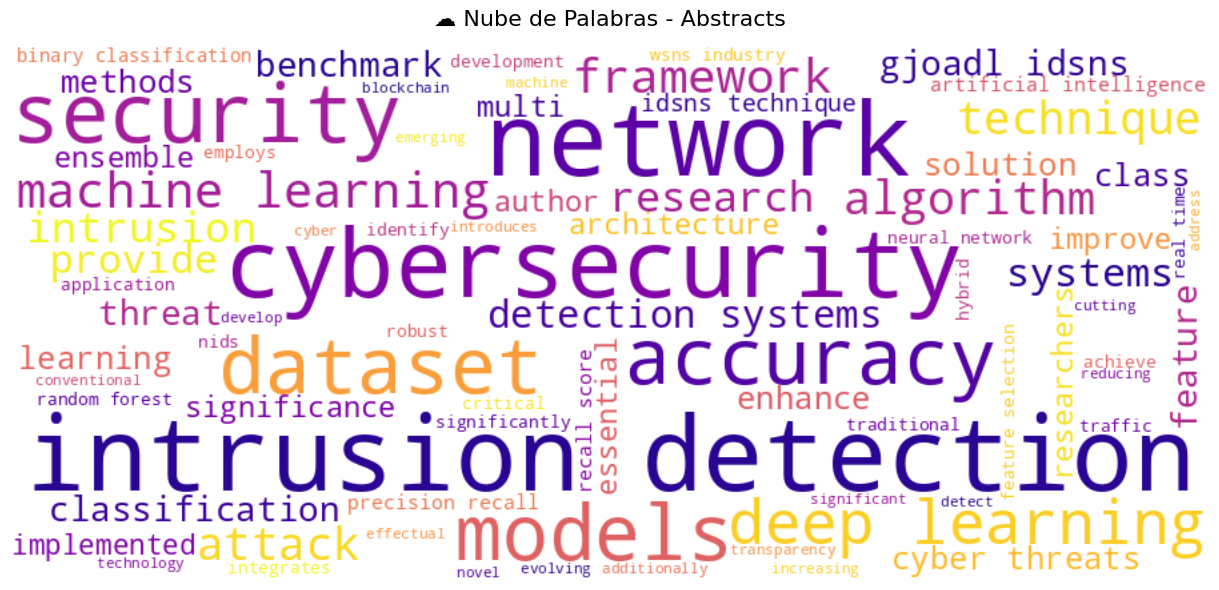

💡 Insight: Las palabras más grandes indican los conceptos dominantes en los abstracts.


In [29]:
#Gráfico 5 : Nube de palabras de abstracts
stopwords_custom = {
    'the','a','an','and','or','of','to','in','for','is','are','this',
    'that','with','on','as','by','we','our','be','from','which','at',
    'it','has','have','been','can','also','into','using','based','these',
    'their','they','were','was','its','than','more','not','use','used',
    'such','two','both','each','paper','study','proposed','approach',
    'model','system','method','results','data','performance','show'
}

text = ' '.join(df['Abstract'].dropna().astype(str)).lower()
words = re.findall(r'\b[a-z]{4,}\b', text)
filtered_text = ' '.join([w for w in words if w not in stopwords_custom])

wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='plasma',
    max_words=80
).generate(filtered_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('☁️ Nube de Palabras - Abstracts', fontsize=16, pad=15)
plt.tight_layout()
plt.show()
print('💡 Insight: Las palabras más grandes indican los conceptos dominantes en los abstracts.')

In [30]:
#gráfico 6: Revistas más publicadas
journals = df['Source title'].value_counts().reset_index()
journals.columns = ['Revista', 'Artículos']

fig = px.pie(
    journals.head(8),
    names='Revista', values='Artículos',
    title='Distribución por Revista Científica',
    hole=0.4
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [33]:
#Conclusiones
print('=' * 60)
print('CONCLUSIONES DEL ANÁLISIS BIBLIOMÉTRICO')
print('=' * 60)
print()
print('1. TENDENCIA TEMPORAL:')
for _, row in pub_year.iterrows():
    print(f'   {int(row["Year"])}: {"█" * int(row["Publicaciones"])} ({int(row["Publicaciones"])} artículos)')
print()
print('2. TÉCNICAS MÁS USADAS (por keywords):')
for kw, freq in kw_counts.most_common(5):
    print(f'   - {kw}: {freq} menciones')
print()
print('3. ARTÍCULO MÁS INFLUYENTE:')
top = df.loc[df['Cited by'].idxmax()]
print(f'   "{top["Title"]}"')
print(f'   Autores: {top["Authors"][:60]}...')
print(f'   Año: {int(top["Year"])} | Citas: {int(top["Cited by"])}')
print()
print('Análisis completado. Exporta el CSV y úsalo en tu app Streamlit.')

CONCLUSIONES DEL ANÁLISIS BIBLIOMÉTRICO

1. TENDENCIA TEMPORAL:
   2020: █ (1 artículos)
   2024: ███ (3 artículos)
   2025: ██████ (6 artículos)

2. TÉCNICAS MÁS USADAS (por keywords):
   - deep learning: 5 menciones
   - machine learning: 5 menciones
   - network security: 4 menciones
   - intrusion detection: 4 menciones
   - cybersecurity: 3 menciones

3. ARTÍCULO MÁS INFLUYENTE:
   "A Situation Based Predictive Approach for Cybersecurity Intrusion Detection and Prevention Using Machine Learning and Deep Learning Algorithms in Wireless Sensor Networks of Industry 4.0"
   Autores: Al-Quayed F.; Ahmad Z.; Humayun M....
   Año: 2024 | Citas: 97

Análisis completado. Exporta el CSV y úsalo en tu app Streamlit.
